## 1.1 Introduzione
### Analisi salute mentale e lavoro


Questo progetto analizza i dati di 1500 lavoratori raccolti nel 2026. L'obiettivo è capire come variabili come lo stress, la produttività e la salute mentale interagiscano tra loro in settori diversi, dal tech alla sanità.

Il problema:

Lo stress e il burnout sono problemi pesanti nelle aziende di oggi. Vogliamo capire cosa faccia scattare i livelli di allerta e se strumenti come il lavoro da remoto o il supporto psicologico servano davvero a qualcosa o se siano inutili.

Le domande che ci siamo fatti:

1. Ore e stress: lavorare di più significa per forza essere più stressati?

2. Smart working e settori: la modalità di lavoro (casa, ufficio o ibrido) cambia in base al tipo di azienda?

3. Età e orari: l'età conta qualcosa nel calcolo delle ore settimanali?

4. Genere e carriera: uomini e donne finiscono a lavorare negli stessi settori o ci sono ancora differenze?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, f_oneway

# Impostazioni grafiche globali
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)

## 1.2 Data Understanding e Preprocessing

Prima di qualsiasi analisi è necessario comprendere la struttura del dataset, verificare la qualità dei dati e preparare le variabili per le analisi successive.

In [ ]:
# Caricamento del dataset fittizio che abbiamo trovato su Kaggle
df = pd.read_csv("mental_health_productivity_2026.csv")

print(f"Dimensioni del dataset: {df.shape[0]} osservazioni x {df.shape[1]} variabili")
df.head()

Dimensioni del dataset: 1500 osservazioni x 13 variabili


,Employee_ID,Age,Gender,Country,Industry,Work_Mode,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours,Mental_Health_Support_Access,Burnout_Risk
0,EMP_0001,50,Male,USA,Manufacturing,Remote,40,9,7.377,89,6.565,Yes,High
1,EMP_0002,36,Male,UK,Finance,Remote,35,1,6.187,61,0.185,Yes,Low
2,EMP_0003,29,Male,Brazil,Finance,Remote,52,4,7.475,47,8.319,No,Low
3,EMP_0004,42,Female,UK,Manufacturing,Remote,56,10,7.169,49,1.747,No,High
4,EMP_0005,40,Male,Germany,Tech,On-site,35,2,9.518,53,5.155,Yes,Low


In [ ]:
# Tipologia delle variabili
var_quant = ['Age', 'Work_Hours_Per_Week', 'Stress_Level',
             'Sleep_Hours', 'Productivity_Score', 'Physical_Activity_Hours']
var_cat   = ['Gender', 'Country', 'Industry', 'Work_Mode',
             'Mental_Health_Support_Access', 'Burnout_Risk']

print("\nVariabili quantitative continue")
for v in var_quant:
    print(f"{v} ({df[v].dtype})")

print("\nVariabili categoriali")
for v in var_cat:
    vals = sorted(df[v].unique())
    print(f"{v}: {vals}")

print("\nValori mancanti per variabile")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Nessun valore mancante rilevato.")


Variabili quantitative continue
Age (int64)
Work_Hours_Per_Week (int64)
Stress_Level (int64)
Sleep_Hours (float64)
Productivity_Score (int64)
Physical_Activity_Hours (float64)

Variabili categoriali
Gender: ['Female', 'Male', 'Non-binary']
Country: ['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Japan', 'Singapore', 'UK', 'USA']
Industry: ['Education', 'Finance', 'Healthcare', 'Manufacturing', 'Retail', 'Tech']
Work_Mode: ['Hybrid', 'On-site', 'Remote']
Mental_Health_Support_Access: ['No', 'Yes']
Burnout_Risk: ['High', 'Low', 'Medium']

Valori mancanti per variabile
Nessun valore mancante rilevato.


### Valori mancanti

Essendo un dataset fittizio, non ci sono valori mancanti (ma sappiamo che nel mondo reale questo non succede mai)

### Tipologia variabili


Quantitative continue: `Age`, `Work_Hours_Per_Week`, `Stress_Level`, `Sleep_Hours`, `Productivity_Score`, `Physical_Activity_Hours`

Categoriali nominali: `Gender`, `Country`, `Industry`, `Work_Mode`, `Mental_Health_Support_Access`, `Burnout_Risk`

Identificatore: `Employee_ID` (non usato nelle analisi)


### Outlier
Abbiamo usato il metodo di Tukey (intervallo interquartile) su tutte le variabili numeriche e il risultato è che non ci sono outlier. Tutti i dati rientrano nei range previsti: non ci sono valori assurdi che dobbiamo cancellare o correggere.

### Conclusione del Preprocessing
In pratica, il dataset fittizio è pulito e pronto all'uso. Non mancano dati, non ci sono errori strani e i formati sono tutti a posto. Non c'è bisogno di fare altro lavoro di pulizia o trasformazione: possiamo passare direttamente a vedere cosa dicono i dati.


## 1.3 Statistica Descrittiva e Visualizzazioni

Calcoliamo le principali misure di posizione e dispersione e produciamo grafici adeguati al tipo di variabile.

In [ ]:
# Misure di posizione e dispersione per le variabili quantitative
desc = df[var_quant].describe().T
desc['median'] = df[var_quant].median()
desc['skewness'] = df[var_quant].skew()
desc = desc[['count','mean','median','std','min','25%','75%','max','skewness']]
desc.columns = ['N','Media','Mediana','Dev.Std','Min','Q1','Q3','Max','Asimmetria']
pd.options.display.float_format = '{:.3f}'.format
desc

,N,Media,Mediana,Dev.Std,Min,Q1,Q3,Max,Asimmetria
Age,1500.000,41.003,42.000,11.063,22.000,31.000,50.000,59.000,-0.085
Work_Hours_Per_Week,1500.000,46.980,47.000,10.042,30.000,38.000,55.250,64.000,-0.003
Stress_Level,1500.000,6.245,7.000,2.988,1.000,4.000,9.000,10.000,-0.284
Sleep_Hours,1500.000,6.973,6.982,1.216,4.000,6.138,7.818,10.000,-0.013
Productivity_Score,1500.000,69.837,70.000,17.397,40.000,55.000,84.000,100.000,0.020
Physical_Activity_Hours,1500.000,5.005,5.023,2.899,0.011,2.526,7.526,9.996,-0.016


**Commento alla tabella descrittiva:**

Age: età media di 41 anni (mediana 42), distribuzione quasi simmetrica.

Work_Hours_Per_Week: media di circa 47 ore/settimana, sopra le classiche 40 ore.

Stress_Level: scala 1–10, media 6.24, mediana 7. Distribuzione leggermente spostata verso valori alti.

Sleep_Hours: media di 6.98 ore/notte, nella norma.

Productivity_Score: media 69.8 su scala 0–100, distribuzione abbastanza uniforme.

Physical_Activity_Hours: media 5 ore/settimana, distribuzione uniforme.

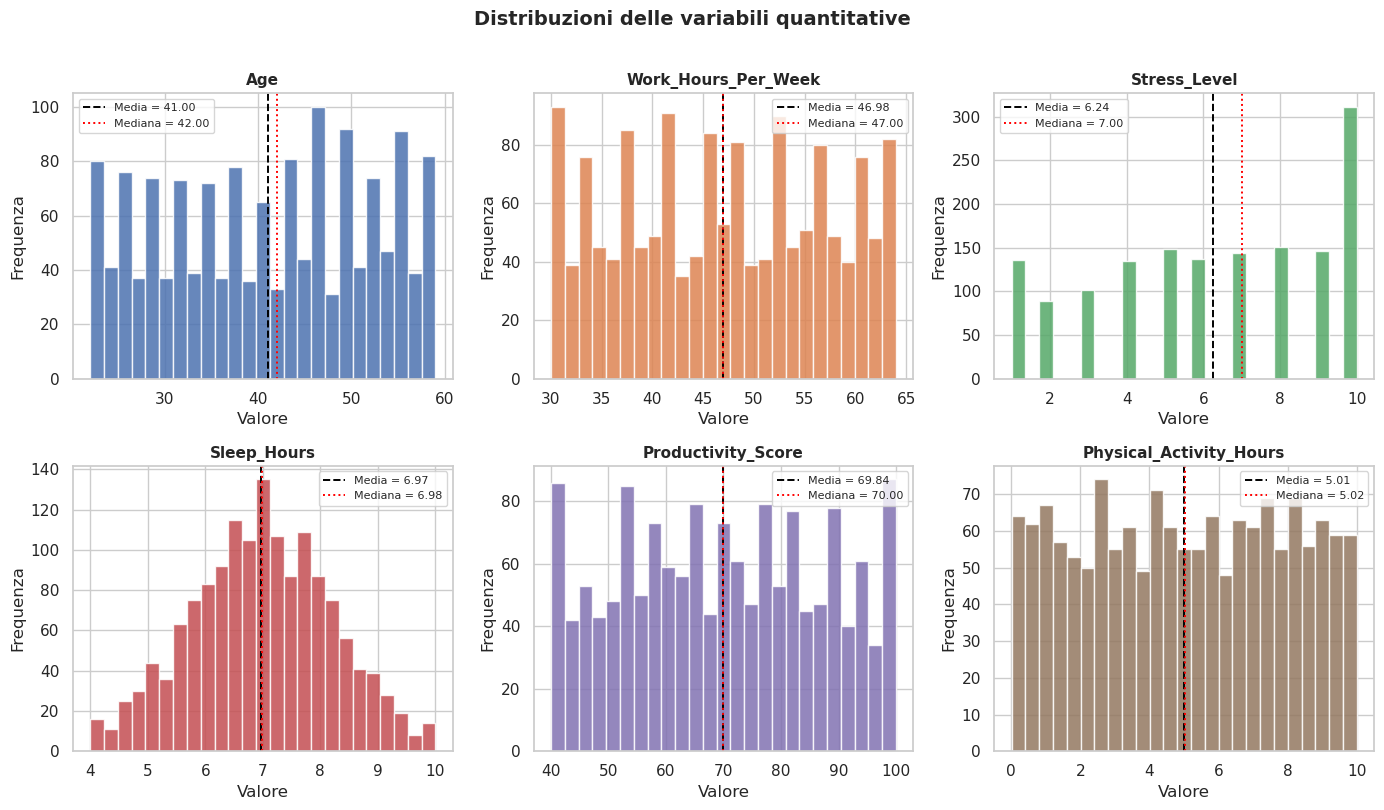

In [ ]:
# Istogrammi delle variabili quantitative principali
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for i, (v, c) in enumerate(zip(var_quant, colors)):
    axes[i].hist(df[v], bins=25, color=c, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[v].mean(), color='black', linestyle='--', linewidth=1.4,
                    label=f'Media = {df[v].mean():.2f}')
    axes[i].axvline(df[v].median(), color='red', linestyle=':', linewidth=1.4,
                    label=f'Mediana = {df[v].median():.2f}')
    axes[i].set_title(v, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valore')
    axes[i].set_ylabel('Frequenza')
    axes[i].legend(fontsize=8)

fig.suptitle('Distribuzioni delle variabili quantitative', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Guardando i grafici, la prima cosa che spunta è che non c'è uno standard: ore di lavoro e produttività sono sparpagliate, segno che ogni dipendente lavora a modo suo... L'età è mista, dai 22 ai 59 anni senza gruppi prevalenti... Però lo stress tende a stare più sui valori alti che su quelli bassi.

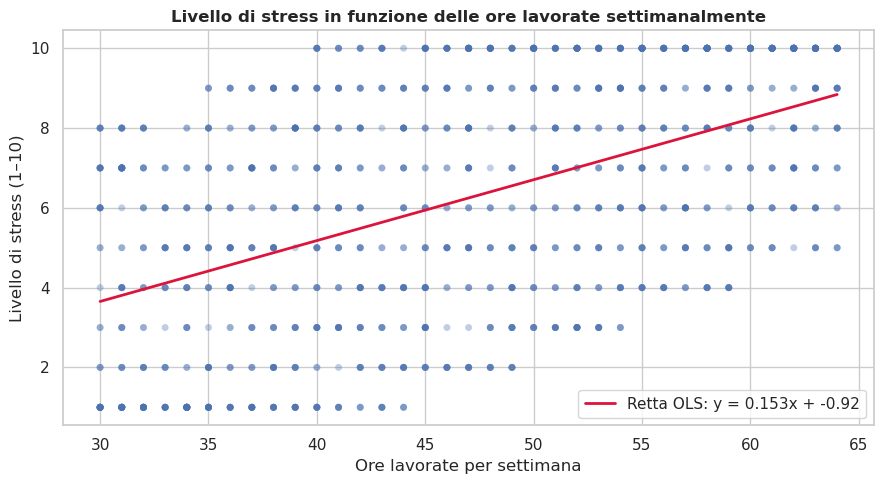

In [ ]:
# Scatterplot: Ore lavorate vs Livello di stress (Q1)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Work_Hours_Per_Week', y='Stress_Level',
                alpha=0.35, color='#4C72B0', edgecolor='none', s=25)

# Retta di regressione
m, b = np.polyfit(df['Work_Hours_Per_Week'], df['Stress_Level'], 1)
x_line = np.linspace(df['Work_Hours_Per_Week'].min(), df['Work_Hours_Per_Week'].max(), 100)
plt.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label=f'Retta OLS: y = {m:.3f}x + {b:.2f}')

plt.title('Livello di stress in funzione delle ore lavorate settimanalmente', fontsize=12, fontweight='bold')
plt.xlabel('Ore lavorate per settimana')
plt.ylabel('Livello di stress (1–10)')
plt.legend()
plt.tight_layout()
plt.show()

Più ore lavorate, più stress. La nuvola di punti è dispersa, quindi le ore non sono l'unico fattore, ma la direzione è chiara.


/tmp/ipykernel_46685/3290350926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Work_Mode', y='Productivity_Score',


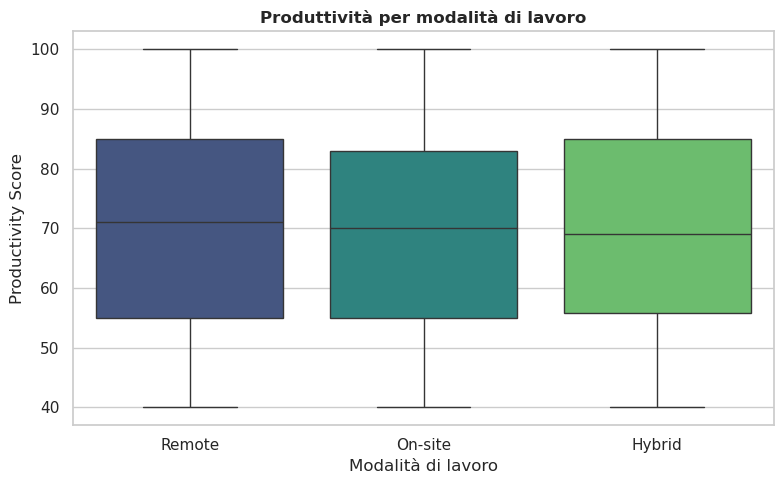

In [ ]:
# Boxplot: Productivity Score per Work Mode
plt.figure(figsize=(8, 5))
order = df.groupby('Work_Mode')['Productivity_Score'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Work_Mode', y='Productivity_Score',
            order=order, palette='viridis')
plt.title('Produttività per modalità di lavoro', fontsize=12, fontweight='bold')
plt.xlabel('Modalità di lavoro')
plt.ylabel('Productivity Score')
plt.tight_layout()
plt.show()

Le distribuzioni della produttività sono praticamente identiche tra remoto, ibrido e in presenza. Le mediane si sovrappongono, il che suggerisce che il modo in cui si lavora non cambia molto la produttività individuale.


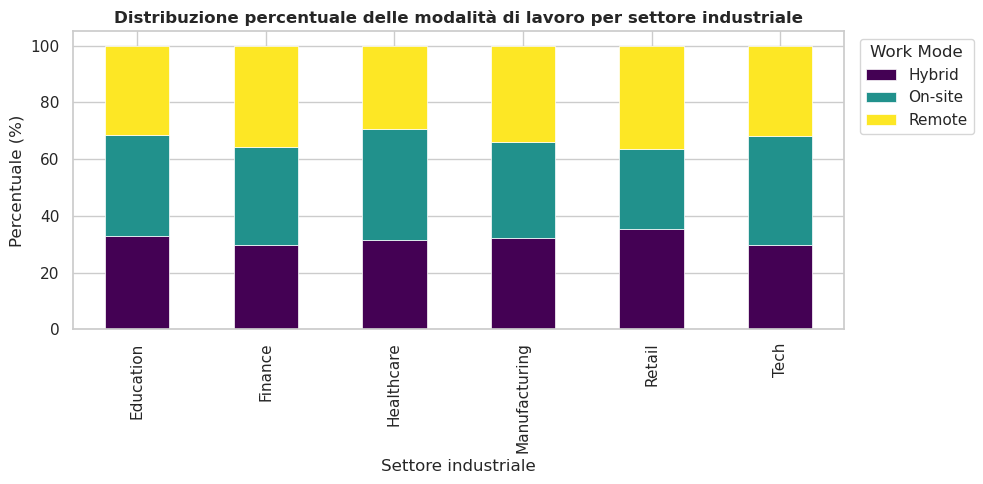

In [ ]:
# Grafico a barre: distribuzione Work_Mode per Industry (Q2 - visualizzazione)
ct_mode_ind = pd.crosstab(df['Industry'], df['Work_Mode'], normalize='index') * 100

ct_mode_ind.plot(kind='bar', stacked=True, figsize=(10, 5),
                 colormap='viridis', edgecolor='white', linewidth=0.5)
plt.title('Distribuzione percentuale delle modalità di lavoro per settore industriale',
          fontsize=12, fontweight='bold')
plt.xlabel('Settore industriale')
plt.ylabel('Percentuale (%)')
plt.legend(title='Work Mode', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Visivamente, la distribuzione delle tre modalità di lavoro appare molto simile tra i settori. In ciascun settore, le percentuali di lavoratori Remote, Hybrid e On-site si avvicinano tutte a circa il 33%, senza che emerga un settore chiaramente più "remoto" o più "in presenza" degli altri.

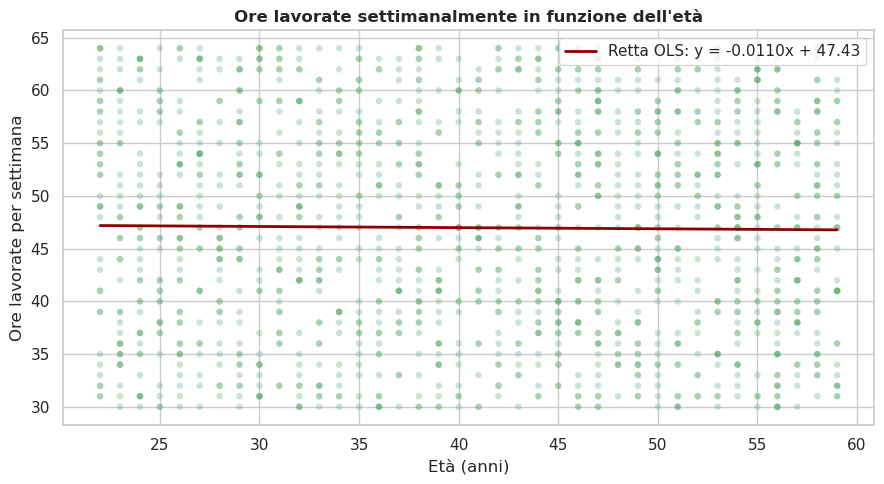

In [ ]:
# Scatterplot: Età vs Ore lavorate (con Jitter, Alpha e Linea di Regressione)\nplt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Work_Hours_Per_Week',
                alpha=0.3, color='#55A868', edgecolor='none', s=22)
m2, b2 = np.polyfit(df['Age'], df['Work_Hours_Per_Week'], 1)
x2 = np.linspace(df['Age'].min(), df['Age'].max(), 100)
plt.plot(x2, m2 * x2 + b2, color='darkred', linewidth=2,
         label=f'Retta OLS: y = {m2:.4f}x + {b2:.2f}')
plt.title('Ore lavorate settimanalmente in funzione dell\'età', fontsize=12, fontweight='bold')
plt.xlabel('Età (anni)')
plt.ylabel('Ore lavorate per settimana')
plt.legend()
plt.tight_layout()
plt.show()

La retta di regressione è quasi orizzontale: nessuna tendenza visibile tra età e ore lavorate. Le due variabili sembrano indipendenti.

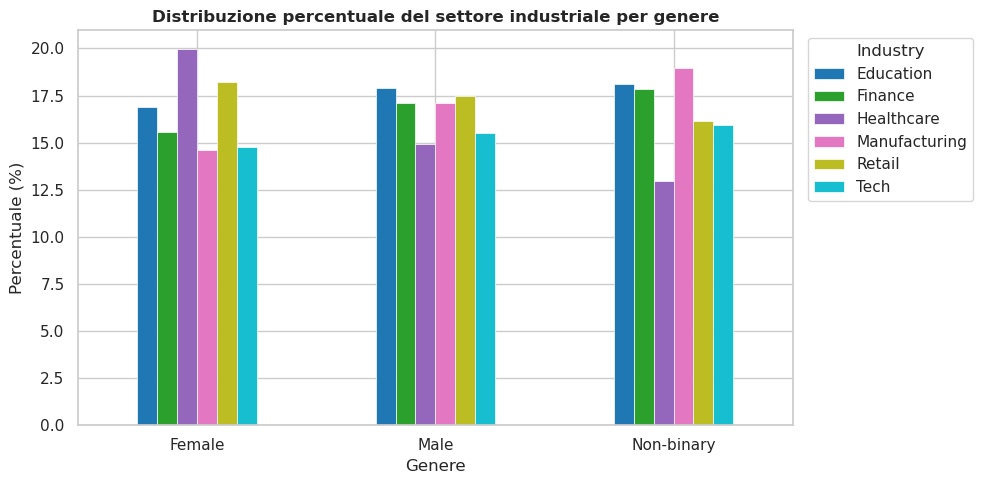

In [ ]:
# Grafico a barre: distribuzione industria per genere (Q4 - visualizzazione)
ct_gen_ind = pd.crosstab(df['Gender'], df['Industry'], normalize='index') * 100

ct_gen_ind.plot(kind='bar', figsize=(10, 5), colormap='tab10',
                edgecolor='white', linewidth=0.5)
plt.title('Distribuzione percentuale del settore industriale per genere',
          fontsize=12, fontweight='bold')
plt.xlabel('Genere')
plt.ylabel('Percentuale (%)')
plt.xticks(rotation=0)
plt.legend(title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Le barre mostrano proporzioni molto simili dei settori industriali tra uomini, donne e persone non-binary. Non emergono pattern evidenti che colleghino un genere a un settore specifico, ad eccezione di una leggera sovra-rappresentazione femminile in Healthcare.

/tmp/ipykernel_46685/275066272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Burnout_Risk', y='Stress_Level',


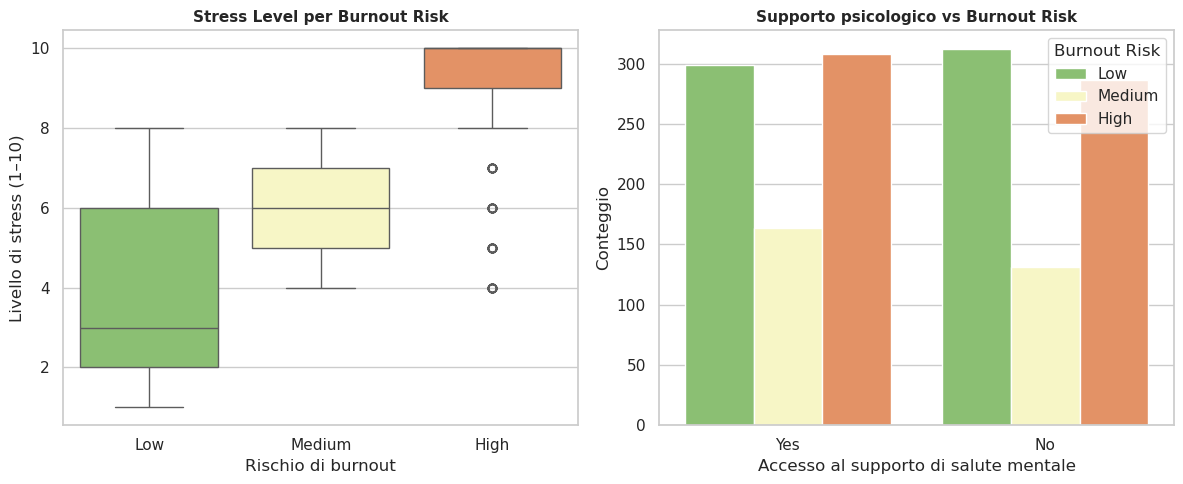

In [ ]:
# Boxplot: Stress Level per Burnout Risk (analisi esplorativa aggiuntiva)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order_burnout = ['Low','Medium','High']
sns.boxplot(data=df, x='Burnout_Risk', y='Stress_Level',
            order=order_burnout, palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Stress Level per Burnout Risk', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Rischio di burnout')
axes[0].set_ylabel('Livello di stress (1–10)')

sns.countplot(data=df, x='Mental_Health_Support_Access',
              hue='Burnout_Risk', hue_order=order_burnout,
              palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('Supporto psicologico vs Burnout Risk', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Accesso al supporto di salute mentale')
axes[1].set_ylabel('Conteggio')
axes[1].legend(title='Burnout Risk')

plt.tight_layout()
plt.show()

Analisando i dati si capisce che più sei stressato, più rischi il burnout.
Il supporto psicologico invece non sembra aiutare tanto, dato che con o senza il supporto il rischio di burnout è lo stesso...


## 1.4 Analisi di Correlazione
Per quantificare le relazioni tra variabili numeriche calcoliamo la correlazione di Pearson, scelta perché entrambe le variabili coinvolte sono quantitative continue e prive di outlier. Affianchiamo sempre la correlazione di Spearman come verifica di robustezza.

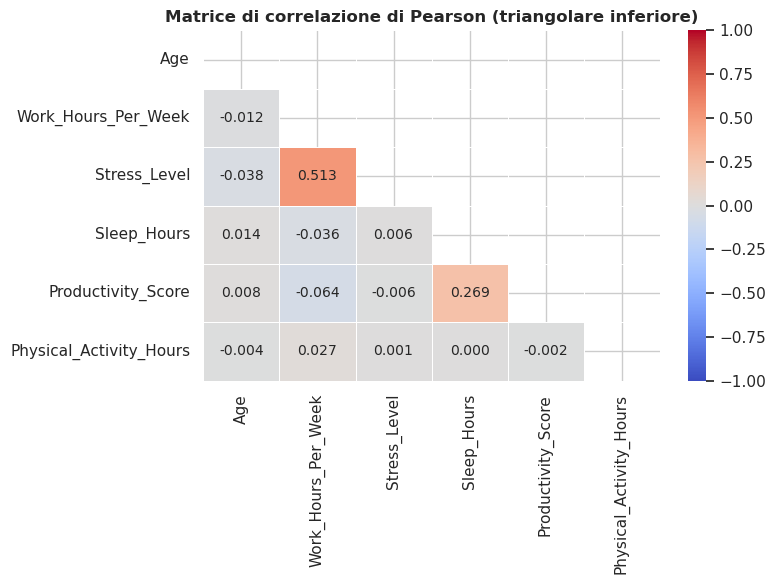

In [ ]:
# Heatmap della matrice di correlazione di Pearson (solo variabili quantitative)
corr_matrix = df[var_quant].corr(method='pearson')

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})
plt.title('Matrice di correlazione di Pearson (triangolare inferiore)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Correlazione tra Work_Hours_Per_Week e Stress_Level

r_pearson, p_pearson = pearsonr(df['Work_Hours_Per_Week'], df['Stress_Level'])
r_spear,   p_spear   = spearmanr(df['Work_Hours_Per_Week'], df['Stress_Level'])
n = len(df)

print("Work_Hours_Per_Week vs Stress_Level")
print(f"  Correlazione di Pearson  r  = {r_pearson:.4f}")
print(f"  p-value (Pearson)           = {p_pearson:.2e}")
print(f"  Correlazione di Spearman ρ  = {r_spear:.4f}")
print(f"  p-value (Spearman)          = {p_spear:.2e}")
print(f"  n = {n}")

Work_Hours_Per_Week vs Stress_Level
  Correlazione di Pearson  r  = 0.5130
  p-value (Pearson)           = 1.89e-101
  Correlazione di Spearman ρ  = 0.5129
  p-value (Spearman)          = 1.98e-101
  n = 1500


correlazione ore lavorate / stress
Il coefficiente a 0.51 conferma che tra ore lavorate e stress c'è un legame diretto: se aumentano le ore, aumenta lo stress. Pearson e Spearman danno lo stesso risultato, quindi il dato è solido e non ci sono errori causati da outlier.

Scontato ma importante: chi lavora oltre le 45 ore a settimana è quasi sempre più stressato. Ovvio che lo stress dipenda anche da altri fattori, come il tipo di capo o l'ambiente, ma i numeri dicono chiaramente che il tempo passato a lavorare è una causa principale. In breve: più ore fai, più rischi il burnout.

correlazione != causalità

In [ ]:
# Correlazione tra Age e Work_Hours_Per_Week

r3_pearson, p3_pearson = pearsonr(df['Age'], df['Work_Hours_Per_Week'])
r3_spear,   p3_spear   = spearmanr(df['Age'], df['Work_Hours_Per_Week'])

print("Age vs Work_Hours_Per_Week")
print(f"  Correlazione di Pearson  r  = {r3_pearson:.4f}")
print(f"  p-value (Pearson)           = {p3_pearson:.4f}")
print(f"  Correlazione di Spearman ρ  = {r3_spear:.4f}")
print(f"  p-value (Spearman)          = {p3_spear:.4f}")
print(f"  n = {n}")

Age vs Work_Hours_Per_Week
  Correlazione di Pearson  r  = -0.0121
  p-value (Pearson)           = 0.6398
  Correlazione di Spearman ρ  = -0.0127
  p-value (Spearman)          = 0.6243
  n = 1500


## 1.5 Analisi Statistica Inferenziale

Sulle variabili categoriali usiamo il test chi-quadro per vedere se ci sono legami reali o se è solo un caso. Per capire quanto è forte questo legame, calcoliamo anche la V di Cramér.

In [ ]:
def cramers_v(chi2, n, r, c):
    """Calcola Cramér's V dalla statistica chi-quadro."""
    k = min(r, c)
    return np.sqrt(chi2 / (n * (k - 1)))

# Chi-quadro Work_Mode vs Industry

ct_Q2 = pd.crosstab(df['Work_Mode'], df['Industry'])
chi2_Q2, p_Q2, dof_Q2, exp_Q2 = chi2_contingency(ct_Q2)
V_Q2 = cramers_v(chi2_Q2, ct_Q2.values.sum(), *ct_Q2.shape)

print("Test chi-quadro — Work_Mode vs Industry")
print("\nTabella di contingenza:")
print(ct_Q2)
print(f"\n  chi-quadro   = {chi2_Q2:.4f}")
print(f"  dof  = {dof_Q2}")
print(f"  p-value = {p_Q2:.4f}")
print(f"  Cramér's V = {V_Q2:.4f}")

Test chi-quadro — Work_Mode vs Industry

Tabella di contingenza:
Industry   Education  Finance  Healthcare  Manufacturing  Retail  Tech
Work_Mode                                                             
Hybrid            87       75          76             81      92    69
On-site           94       87          94             85      73    88
Remote            83       90          71             86      95    74

  chi-quadro   = 9.9802
  dof  = 10
  p-value = 0.4422
  Cramér's V = 0.0577


In [ ]:
# Chi-quadro Gender vs Industry

ct_Q4 = pd.crosstab(df['Gender'], df['Industry'])
chi2_Q4, p_Q4, dof_Q4, exp_Q4 = chi2_contingency(ct_Q4)
V_Q4 = cramers_v(chi2_Q4, ct_Q4.values.sum(), *ct_Q4.shape)

print("Q4: Test chi-quadro — Gender vs Industry")
print("\nTabella di contingenza (frequenze osservate):")
print(ct_Q4)
print(f"\n  chi-quadro   = {chi2_Q4:.4f}")
print(f"  dof  = {dof_Q4}")
print(f"  p-value = {p_Q4:.4f}")
print(f"  Cramér's V = {V_Q4:.4f}")

Q4: Test chi-quadro — Gender vs Industry

Tabella di contingenza (frequenze osservate):
Industry    Education  Finance  Healthcare  Manufacturing  Retail  Tech
Gender                                                                 
Female             88       81         104             76      95    77
Male               91       87          76             87      89    79
Non-binary         85       84          61             89      76    75

  chi-quadro   = 12.8543
  dof  = 10
  p-value = 0.2319
  Cramér's V = 0.0655


### Gender vs Industry

L'ipotesi di partenza è che il genere non influenzi il settore in cui si lavora. Con un p-value di 0.23, che è molto più alto del limite di 0.05, non possiamo scartare questa idea. In pratica, non c'è nessuna prova statistica che uomini e donne scelgano settori diversi in questo dataset, e anche la V di Cramér è bassissima (0.065).


In [ ]:
# Intervallo di confidenza al 95% per lo Stress Level medio

mu_stress = df['Stress_Level'].mean()
se_stress  = stats.sem(df['Stress_Level'])
ci_stress  = stats.t.interval(0.95, df=len(df)-1, loc=mu_stress, scale=se_stress)

print("Intervallo di confidenza al 95% — Stress Level medio")
print(f"  Media campionaria  = {mu_stress:.4f}")
print(f"  Errore standard    = {se_stress:.4f}")
print(f"  IC 95%             = ({ci_stress[0]:.4f}, {ci_stress[1]:.4f})")
print(f"  n = {n}")

Intervallo di confidenza al 95% — Stress Level medio
  Media campionaria  = 6.2447
  Errore standard    = 0.0771
  IC 95%             = (6.0934, 6.3960)
  n = 1500


## 1.6 Conclusioni e Limiti

### Risposte alle domande statistiche

**Q1** Correlazione lineare positiva tra ore lavorate e stress? Sì, correlazione positiva moderata-forte, statisticamente significativa

**Q2** La distribuzione delle modalità di lavoro varia tra settori? No, nessuna associazione significativa

**Q3** L'età influenza le ore lavorate? No, le due variabili risultano indipendenti

**Q4** Associazione significativa tra genere e settore industriale? No, ancora nessuna associazione significativa

### Sintesi

L'unico risultato significativo è la correlazione tra ore lavorate e stress: lavorare di più è associato a più stress, in modo robusto e coerente con la letteratura. Tutte le altre relazioni analizzate, modalità di lavoro vs settore, età vs ore lavorate, genere vs settore , non raggiungono la significatività statistica. Il livello medio di stress nel campione è 6.24/10, medio-alto.

### Limiti

Il dataset è osservazionale, quindi non si possono stabilire relazioni causali. Le distribuzioni molto uniformi delle variabili (età, settori) suggeriscono un possibile campionamento stratificato , il che limita la generalizzabilità dei risultati. Sarebbe più interessenta se ci fossero altre variabili rilevanti tipo stipendio, ruolo e anzianità. Infine, aggregare 10 paesi con normative e culture del lavoro molto diverse può mascherare differenze importanti.

